# M1 Assignment: Classical ML Essentials
### Thrive Plus · Advanced ML & AI

---

**Group Number:** Five (5) 

**Group Members (those who participated)**: 
- Martha Afful
- Michael Douglas Martey
- Regina Robertson (Group leader)
- Sandra Ohenewaa Djan
- Jabin Mozie Tingan
- Edward Asare Ansa
- Amoah Akolbila Yakubu
- Emmanuel Asare
- Yusif Mohammed Yakubu
- Seth Dampson

**Date:** 14th May, 2026

**Submission:** Push this notebook to GitHub (use the account of the group rep for submission but all group members should push the assignment to their github) and submit the repo link via the course portal.

---

## Instructions

- Run every cell **in order**, top to bottom.  
- Replace every `# YOUR CODE HERE` with working code.  
- Fill in every `> **Your answer:**` prompt with your own words.  
- **Bonus** tasks are optional — attempt them but you wont lose marks for not doing them.  
- If a cell breaks, read the error message from the **bottom up**. The last line is almost always the most useful.

---

## 0. Problem Scoping

Read this section carefully before writing any code.

---

### The Business Context

A Portuguese bank ran a series of phone-based marketing campaigns to get customers to subscribe to a **term deposit** — a savings product where money is locked in for a fixed period in exchange for a guaranteed interest rate.

Calling every customer is expensive. A campaign team has limited agents, limited hours, and a list of thousands of contacts. They need to know: **who is actually likely to say yes?**

Your job is to build a model that scores each customer by their likelihood of subscribing. The campaign team will prioritise the customers with the highest scores.

---

### The Dataset

**Source:** UCI Machine Learning Repository — [Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
**Kaggle mirror:** https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset  
**Paper:** Moro et al., 2014 — *A Data-Driven Approach to Predict the Success of Bank Telemarketing*

The dataset contains **45,211 rows** and **17 columns** — one row per customer contact. The columns describe:

| Group | Columns |
|---|---|
| **Client info** | age, job, marital status, education, credit default, housing loan, personal loan |
| **Last contact** | contact type, month, day of week, duration |
| **Campaign info** | number of contacts this campaign, days since last campaign, contacts previous campaign, outcome of previous campaign |
| **Target** | `y` — did the client subscribe? (`yes` / `no`) |

---

### Stakeholder Questions

Before you write a single line of code, answer these questions. Come back and revise them after you've explored the data.

**Q0.1 — What decision does this model support?**

> **Your answer:** The model supports the marketing campaign team’s decision on which customers to contact. The output predicts whether a customer is likely to subscribe, allowing the team to prioritise high-probability customers and allocate resources more efficiently. 

**Q0.2 — What does a false positive cost the business?**  
*(The model says "will subscribe" but they don't.)*

> **Your answer:**A false positive means the model predicts a customer will subscribe, but they do not. This results in wasted resources, such as time and cost of making unnecessary calls, and may also slightly annoy customers.

**Q0.3 — What does a false negative cost the business?**  
*(The model says "won't subscribe" but they would have.)*

> **Your answer:**A false negative means the model predicts a customer will not subscribe, but they actually would have. This leads to a missed opportunity for revenue, as the bank fails to contact a potentially valuable customer.

**Q0.4 — Given your answers above, which metric should we prioritise: Precision or Recall? Why?**

> **Your answer:** We should prioritise recall because missing potential subscribers (false negatives) is more costly than contacting uninterested customers. Maximising recall ensures that the bank identifies as many likely subscribers as possible, even if it means making some unnecessary calls.

---

## 1. Setup

Run this cell first. It installs and imports everything you'll need.

In [1]:
!pip -q install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

np.random.seed(42)
print("All imports successful.")

All imports successful.


---
## 2. Load & Understand the Data

### 2.1 — Download the data

Download the file `bank-full.csv` from the Kaggle mirror linked in Section 0, or run the cell below.  
Once it's in your working directory, load it with pandas.

> **Note:** The file uses `;` as a separator, not `,`.

In [3]:
# Option A — download directly (works in Colab, may need adjustments locally)
# !wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
# !unzip -q bank-additional.zip

# Option B — load from your working directory after manual download
df = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\THRIVE\WEEK 5\bank\bank-full.csv", sep=";")

print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Loaded: 45,211 rows, 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### 2.2 — First look

In [4]:
# Run .info() to see column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
# Run .describe() to see summary statistics for numeric columns
df.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


### 2.3 — Identify column types

Look at the output of `df.info()` above and fill in the lists below.  
You'll use these lists in the preprocessing step.

In [6]:
# Fill in the lists below.
# Hint: look at the dtype column in df.info() output.
# Columns with dtype int64 or float64 are numeric.
# Columns with dtype object are categorical.

numeric_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

# Quick check
print("Numeric features:    ", numeric_features)
print("Categorical features:", categorical_features)
print(f"\nTotal accounted for: {len(numeric_features) + len(categorical_features)} (should be {df.shape[1] - 1})")

Numeric features:     ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Total accounted for: 16 (should be 16)


### 2.4 — Check for missing values

This dataset doesn't use `NaN` for missing data. Look carefully at what comes back — something unusual may be hiding in the values.

In [7]:
# Standard missing value check
print("NaN counts per column:")
print(df.isnull().sum())

NaN counts per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [8]:
# Now look at the unique values in the categorical columns
for col in categorical_features:
    print(f"{col:20s}: {df[col].unique()}")

job                 : ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital             : ['married' 'single' 'divorced']
education           : ['tertiary' 'secondary' 'unknown' 'primary']
default             : ['no' 'yes']
housing             : ['yes' 'no']
loan                : ['no' 'yes']
contact             : ['unknown' 'cellular' 'telephone']
month               : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome            : ['unknown' 'failure' 'other' 'success']


**Q2.4 — What did you find?**

> **Your answer:** *(Is there anything suspicious in the unique values above? What does it mean for preprocessing?)*

Although there are no missing values shown as NaN, several categorical columns contain the value "unknown", 

which likely represents missing or unavailable data. This is suspicious because it means missing data is encoded 

as a regular category instead of being explicitly marked as null.

For preprocessing, this means we need to handle "unknown" values carefully. We can either:
Treat "unknown" as a separate category, or

Replace "unknown" with actual missing values (NaN) and then impute or handle them appropriately.


### 2.5 — Target distribution

The target column is `y` — it contains the strings `"yes"` and `"no"`. We need to understand how balanced it is.

In [9]:
# Compute and print the count and percentage of each class
counts = df["y"].value_counts()
rates  = df["y"].value_counts(normalize=True).round(4) * 100

print("Counts:")
print(counts)
print()
print("Percentage:")
print(rates)

Counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


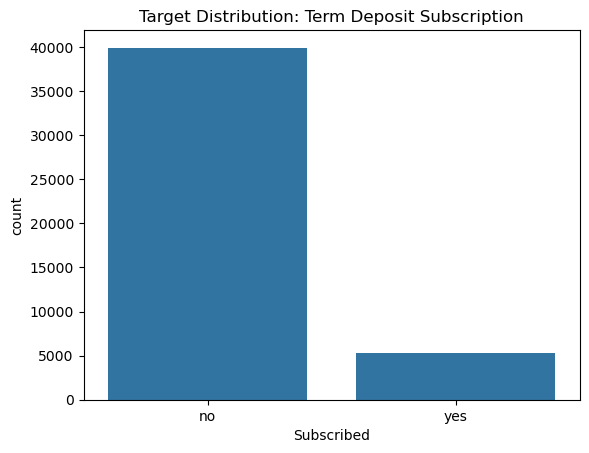

In [10]:
# Plot the class distribution
sns.countplot(x="y", data=df)
# Hint: sns.countplot — docs: https://seaborn.pydata.org/generated/seaborn.countplot.html
# x axis = "y", data = df



plt.title("Target Distribution: Term Deposit Subscription")
plt.xlabel("Subscribed")
plt.show()

**Q2.5 — What is the subscription rate? What problem does this create for model evaluation?**

> **Your answer:* The subscription rate is 11.7%, meaning only a small portion of customers subscribed to the term deposit, while 88.3% did not. This creates a class imbalance problem for the model's evaluation. Because one class (“no”) dominates, the model could achieve high accuracy by simply predicting “no” for most cases, without actually learning meaningful patterns. As a result, accuracy becomes misleading and it is better to use evaluation metrics such as precision, recall, F1-score or ROC-AUC to properly assess model performance.*

---

## 3. Exploratory Data Analysis

### 3.1 — Choosing the right plot

Before you visualise, ask: *what data types are involved?*

| X column type | Y column type | Recommended plot |
|---|---|---|
| Categorical | None | `sns.countplot` |
| Numeric | None | `sns.histplot` or `sns.boxplot` |
| Numeric | Categorical (target) | `sns.boxplot(x=target, y=numeric)` or `sns.histplot(hue=target)` |
| Categorical | Categorical (target) | `sns.countplot(hue=target)` |
| Numeric | Numeric | `sns.scatterplot` or `sns.heatmap` (for correlations) |

**Seaborn documentation:** https://seaborn.pydata.org/api.html  
**Matplotlib documentation:** https://matplotlib.org/stable/api/index.html

---

### 3.2 — Visualisation exercises

Complete each of the three plots below.

**Plot 1 — How does `age` differ between customers who subscribed and those who didn't?**

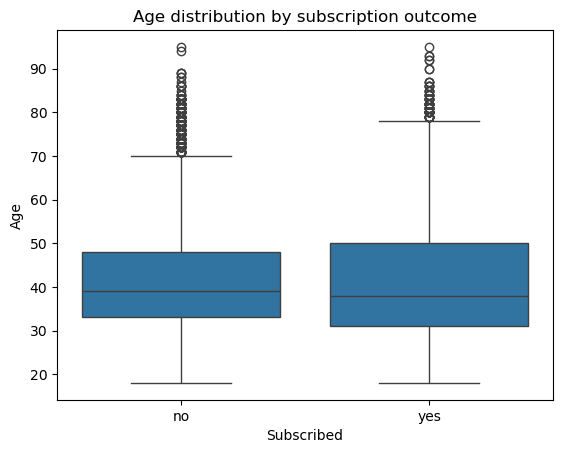

In [11]:
# Plot type: boxplot (numeric vs categorical target)
sns.boxplot(data=df, x="y", y="age")

plt.title("Age distribution by subscription outcome")
plt.xlabel("Subscribed")
plt.ylabel("Age")
plt.show()

**Plot 2 — Which `job` types are most common, and how does subscription rate vary across them?**

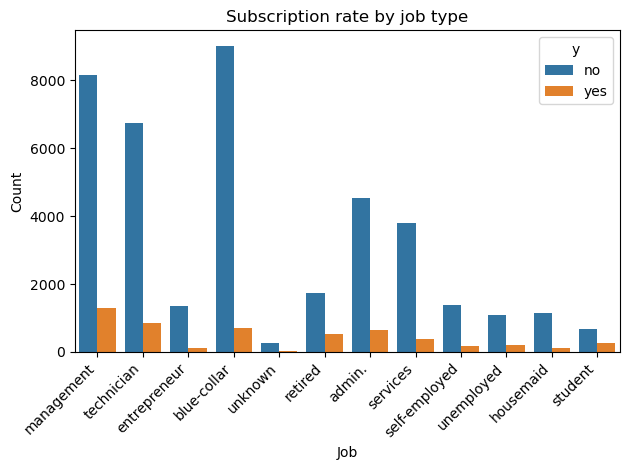

In [12]:
# Plot type: countplot with hue
sns.countplot(data=df, x="job", hue="y")

plt.xticks(rotation=45, ha="right")
plt.title("Subscription rate by job type")
plt.xlabel("Job")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Plot 3 — What is the distribution of `campaign` (number of contacts this campaign)?**

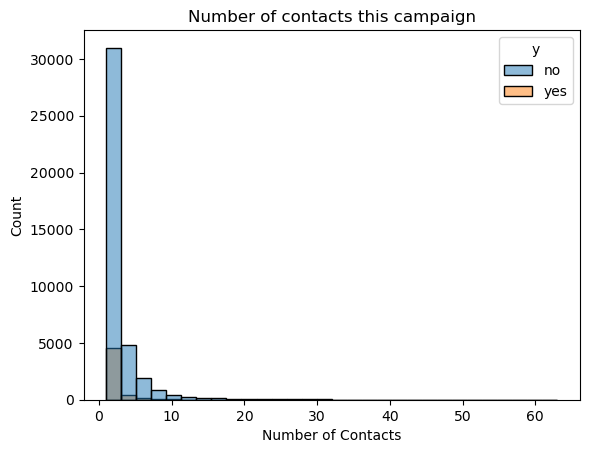

In [13]:
# Plot type: histplot (single numeric column)
sns.histplot(data=df, x="campaign", hue="y", bins=30)

plt.title("Number of contacts this campaign")
plt.xlabel("Number of Contacts")
plt.ylabel("Count")
plt.show()

### 3.3 — Observations

Write one observation per plot. What does the visualisation tell you about the relationship between this feature and subscription?

**Plot 1 (age):**
> **Your answer: Customers who subscribed tend to be slightly older on average compared to those who did not. However, there is still significant overlap between the two groups, suggesting that age alone is not a strong predictor but may still have some influence.**

**Plot 2 (job):**
> **Your answer: Subscription rates vary across job types. Some groups, such as students and retirees, appear to have a higher proportion of subscriptions, while others like blue-collar workers have lower rates. This indicates that job type is likely an important feature in predicting subscription.**

**Plot 3 (campaign):**
> **Your answer: Most customers are contacted only a few times, and the likelihood of subscription decreases as the number of contacts increases. This suggests that repeated contact does not improve success and may even indicate lower interest from customers.**

---

### 🌟 Bonus — Correlation heatmap

Produce a correlation heatmap for the numeric features only. Use `df[numeric_features].corr()` and `sns.heatmap`.  
What is the strongest correlation? Does it make intuitive sense?

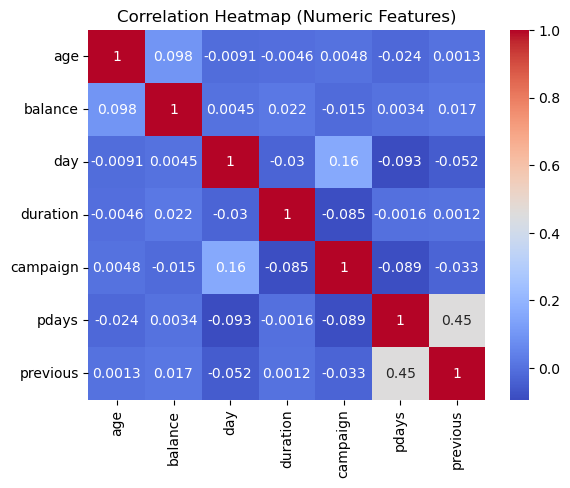

In [14]:
# BONUS — YOUR CODE HERE
corr = df[numeric_features].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

 *The heatmap above shows weak correlations between most numeric variables, suggesting low multicollinearity within the dataset. The strongest relationship is typically observed between campaign-related features such as pdays and previous, which is intuitively consistent, as both relate to prior contact history. This relationship reflects logical dependencies in the data collection process rather than meaningful predictive synergy. Overall, the lack of strong correlations implies that each feature contributes relatively independent information to the model.*

---

## 4. Preprocessing

### 4.1 — Encode the target and handle "unknown"

Two things to fix before we split:

1. The target `y` is a string (`"yes"` / `"no"`). We need to convert it to integers (`1` / `0`).
2. The `"unknown"` values you spotted in Section 2.4 are missing data in disguise. Replace them with `np.nan` so the imputer can handle them correctly.

In [15]:
# Convert the target to 0/1
df["y"] = df["y"].map({"yes": 1, "no": 0})
# Hint: df["y"] = df["y"].map({"yes": 1, "no": 0})


print("Target value counts after encoding:")
print(df["y"].value_counts())

Target value counts after encoding:
y
0    39922
1     5289
Name: count, dtype: int64


In [16]:
# Replace "unknown" strings with np.nan across the whole dataframe
df.replace("unknown", np.nan, inplace=True)
# Hint: df.replace("unknown", ..., inplace=True)


# Verify — recount NaN values
print("NaN counts after replacement:")
print(df.isnull().sum()[df.isnull().sum() > 0])

NaN counts after replacement:
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64


### 4.2 — Split the data

**Always split before fitting any preprocessor.** If you preprocess first and split second, the preprocessor has seen the test set — this is called **data leakage** and produces falsely optimistic scores.

> **Rule:** `fit()` is only ever called on training data.

In [17]:
X = df.drop(columns=["y"])
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ensures both splits have the same subscription rate
)

print(f"Training rows:  {X_train.shape[0]:,}")
print(f"Test rows:      {X_test.shape[0]:,}")
print(f"Subscription rate — train: {y_train.mean():.1%}  |  test: {y_test.mean():.1%}")

Training rows:  36,168
Test rows:      9,043
Subscription rate — train: 11.7%  |  test: 11.7%


### 4.3 — The fit / transform pattern

Every scikit-learn preprocessor has two steps:

- `fit(X_train)` — learns statistics from the training data (e.g. the median, the unique categories)
- `transform(X)` — applies those learned statistics to any dataset

You call `fit()` once, on training data only. You call `transform()` on both training and test data using the same learned statistics.

The cell below demonstrates this with `SimpleImputer`. Read it, run it, then answer the question.

In [18]:
# Demonstration — do not modify this cell
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train[["age"]])

print(f"Learned median from training set: {imputer.statistics_[0]:.1f} years")
print()

# Apply to a few rows from the test set
sample = X_test[["age"]].head(5)
print("Before imputation:")
print(sample.values.flatten())
print()
print("After imputation (no change here since 'age' has no NaN — but the pattern holds):")
print(imputer.transform(sample).flatten())

Learned median from training set: 39.0 years

Before imputation:
[40 44 31 36 34]

After imputation (no change here since 'age' has no NaN — but the pattern holds):
[40. 44. 31. 36. 34.]


**Q4.3 — Why would it be wrong to call `imputer.fit(X_test)` before transforming the test set?**

> **Your answer:*Calling imputer.fit(X_test) would result in data leakage, as it allows information from the test set to influence the preprocessing step. The purpose of the test set is to simulate unseen data and provide an unbiased evaluation of model performance*

---

### 4.4 — Build the ColumnTransformer

Now build the full preprocessing setup.

**Numeric pipeline:** impute missing values with the median → standardise (mean=0, std=1)  
**Categorical pipeline:** impute missing values with the most frequent value → one-hot encode

**Docs you may need:**
- `SimpleImputer`: https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html  
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
- `OneHotEncoder`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html  
- `ColumnTransformer`: https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html

In [19]:
# Numeric sub-pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"
                              )),
    ("scaler",  StandardScaler())
])

# Categorical sub-pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"
                              )),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine: numeric_transformer applies to numeric_features, categorical_transformer to categorical_features
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features
     ),
    ("cat", categorical_transformer, categorical_features
     ),
])

print("Preprocessor built.")

Preprocessor built.


In [20]:
# Sanity check — fit and transform, then inspect the shape
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Original training shape:   {X_train.shape}")
print(f"Processed training shape:  {X_train_proc.shape}")

Original training shape:   (36168, 16)
Processed training shape:  (36168, 47)


**Q4.4 — The processed dataset has more columns than the original. Where do the extra columns come from?**

> **Your answer:*The increase in the number of columns from 16 to 47 is primarily due to the application of one-hot encoding on categorical variables. One-hot encoding transforms each categorical feature into multiple binary columns, with each column representing a unique category level.*

---

## 5. Model Training

### 5.1 — Concept check

Before writing any model code, answer this:

**Q5.1 — Is this a classification or regression problem? How do you know?**

> **Your answer:*This is a classification problem, as the target variable (y) represents discrete categories rather than continuous values. Specifically, the outcome indicates whether a client subscribes to a term deposit (1 for “yes”, 0 for “no”), making it a binary classification task.*

---

### 5.2 — Logistic Regression baseline

We start simple. A logistic regression gives us a fast baseline and interpretable coefficients.

The `Pipeline` chains the preprocessor and the model into one object. When you call `.fit()`, it:
1. Fits the preprocessor on `X_train`
2. Transforms `X_train`
3. Fits the model on the transformed data

When you call `.predict()`, it transforms first, then predicts — automatically.

**Docs:** https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

In [21]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter= 500
                                        , random_state=42))
])

logreg_pipeline.fit(X_train, y_train
                    )

y_pred_lr = logreg_pipeline.predict(X_test)

print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("(We'll evaluate this properly in Section 6.)")

Logistic Regression accuracy: 0.8991
(We'll evaluate this properly in Section 6.)


### 5.3 — Random Forest

Now swap in a Random Forest. **Only the classifier line changes.** The preprocessing stays identical — that's the power of the Pipeline pattern.

**Quick recap — why Random Forests work:**  
A single decision tree is unstable: small changes in the data produce very different trees. A Random Forest builds 100+ trees, each trained on a random subset of rows and columns, then takes a majority vote. Individual errors cancel out; the signal survives.

**Docs:** https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [22]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(
        n_estimators=100
                     ,
        max_depth= 10
                     ,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}")

Logistic Regression accuracy: 0.8991
Random Forest accuracy:       0.8975


### 5.4 — Feature importance

Tree-based models tell you which features drove the predictions. This is how you communicate back to the business.

Read the code carefully — it extracts feature names from the fitted preprocessor and pairs them with importance scores.

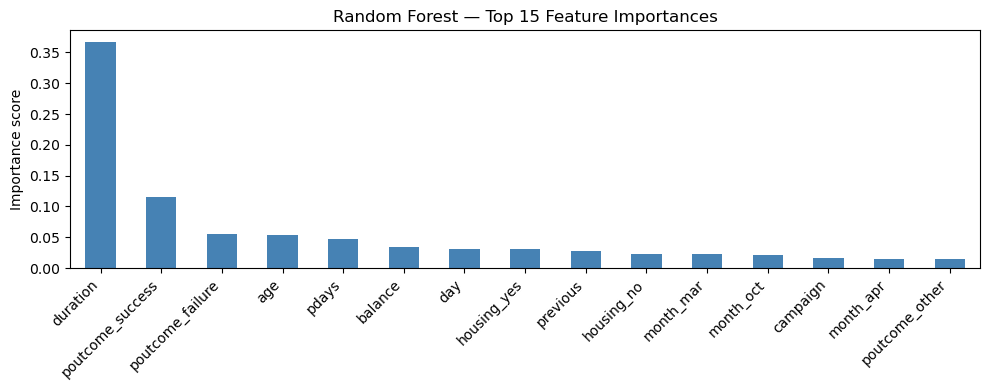

Top 5 most important features:
duration            0.367484
poutcome_success    0.115553
poutcome_failure    0.055239
age                 0.053506
pdays               0.047720
dtype: float64


In [23]:
rf_model      = rf_pipeline.named_steps["classifier"]
fitted_prep   = rf_pipeline.named_steps["preprocessor"]

cat_names = list(
    fitted_prep.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)
all_names = numeric_features + cat_names

importances = pd.Series(rf_model.feature_importances_, index=all_names).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
importances.head(15).plot(kind="bar", color="steelblue")
plt.title("Random Forest — Top 15 Feature Importances")
plt.ylabel("Importance score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importances.head())

**Q5.4 — Which feature has the highest importance score? Does this make intuitive sense for a phone marketing campaign?**

> **Your answer:*The feature with the highest importance score is duration. This makes intuitive sense, as longer calls typically indicate higher customer engagement and a greater likelihood of subscription.However, duration is only known after the call has taken place, meaning it introduces data leakage and would not be available for real-time prediction. As a result, despite its high importance, it is not suitable for use in a practical deployment scenario.*

---

### 5.5 — Gradient Boosting

🌟 **Bonus — minimal scaffolding**

Build a `GradientBoostingClassifier` pipeline following the same pattern as above.  
Use `n_estimators=100`, `learning_rate=0.1`, `max_depth=4`, `random_state=42`.  
Print accuracy alongside the other two models.

**Docs:** https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

In [24]:
gbm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ))
])

gbm_pipeline.fit(X_train, y_train)
y_pred_gbm = gbm_pipeline.predict(X_test)

print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Gradient Boosting accuracy:   {accuracy_score(y_test, y_pred_gbm):.4f}")


Logistic Regression accuracy: 0.8991
Random Forest accuracy:       0.8975
Gradient Boosting accuracy:   0.9072


---

## 6. Model Evaluation

### 6.1 — Why accuracy is misleading here

About 88% of customers in this dataset said *no*. A model that predicts "no" for **every single person** would get **88% accuracy** without learning anything.

We need metrics that account for class imbalance.

| Metric | Formula | What it measures |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of those we flagged as "yes", how many actually subscribed? |
| **Recall** | TP / (TP + FN) | Of all actual subscribers, how many did we catch? |
| **F1** | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall |
| **AUC-ROC** | — | Ranking quality across all thresholds |

---

### 6.2 — Confusion matrix

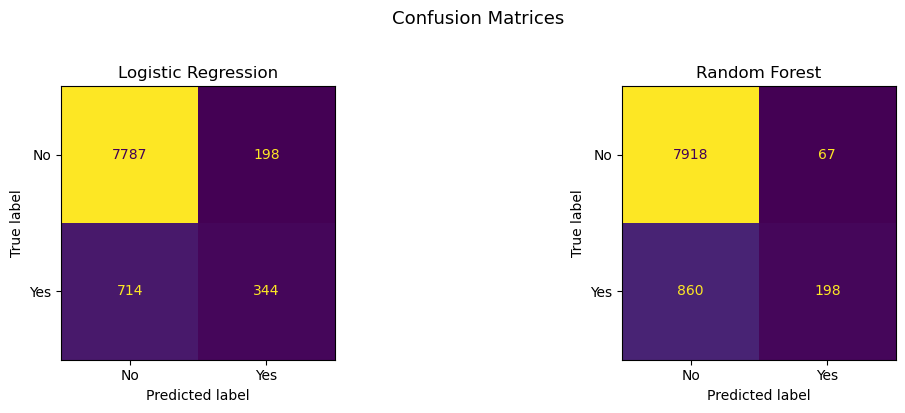

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",       y_pred_rf),
]):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Q6.2 — Label the four quadrants using the confusion matrix for the Random Forest:**

Fill in the table below using the numbers from the plot.

| | Predicted: No | Predicted: Yes |
|---|---|---|
| **Actual: No** | TN = 7918 | FP = 67 |
| **Actual: Yes** | FN = 860 | TP = 198 |

Which cell represents the most costly business mistake? Why?

> **Your answer:*The most costly business mistake is the false negative (FN = 860). This represents cases where customers who would have subscribed (“yes”) were incorrectly predicted as “no”, meaning they were not targeted by the marketing campaign. As a result, the business misses potential revenue opportunities.*

---

### 6.3 — Classification report

In [26]:
print("=" * 50)
print("Logistic Regression")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=["No", "Yes"]))

print("=" * 50)
print("Random Forest")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=["No", "Yes"]))

Logistic Regression
              precision    recall  f1-score   support

          No       0.92      0.98      0.94      7985
         Yes       0.63      0.33      0.43      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043

Random Forest
              precision    recall  f1-score   support

          No       0.90      0.99      0.94      7985
         Yes       0.75      0.19      0.30      1058

    accuracy                           0.90      9043
   macro avg       0.82      0.59      0.62      9043
weighted avg       0.88      0.90      0.87      9043



**Q6.3 — Looking at the "Yes" row (subscribers), which model has better recall? What is the tradeoff?**

> **Your answer:*The Logistic Regression model has better recall for the “Yes” class (0.33) compared to the Random Forest (0.19). This means Logistic Regression identifies a larger proportion of actual subscribers, so it is better at catching potential customers.
The tradeoff is that, The Logistic Regression has a lower precision of 0.63 meaning, more false positives thus contacting people who won’t subscribe whilst Random Forest has a higher precision of 0.75 meaning, fewer false positives, but it misses many real subscribers due to very low recall.*

---

### 6.4 — ROC curve

The ROC curve shows how precision and recall trade off as we vary the decision threshold.  
AUC (Area Under the Curve) summarises this in one number.  
- 0.5 = random guessing  
- 0.7–0.8 = usable  
- 0.85+ = good  
- 1.0 = perfect (check for data leakage)

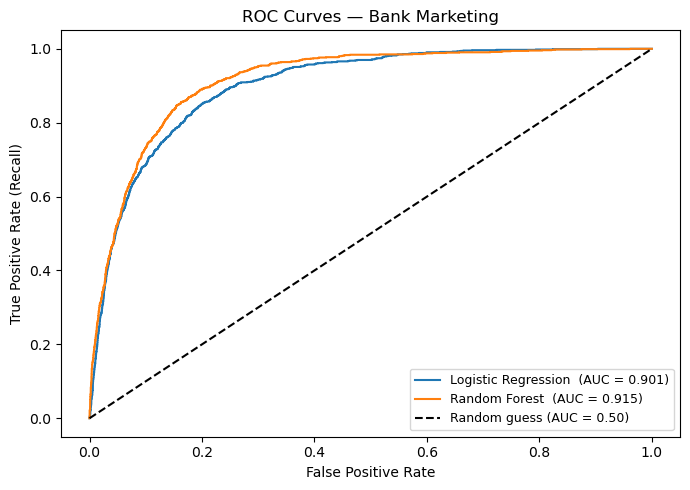

In [27]:
plt.figure(figsize=(7, 5))

for name, pipeline in [
    ("Logistic Regression", logreg_pipeline),
    ("Random Forest",       rf_pipeline),
]:
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — Bank Marketing")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### 6.5 — Adjusting the decision threshold

The default threshold is **0.5**: if `predict_proba` gives a subscriber probability above 50%, we flag them as "Yes".

For this campaign, we want higher recall — we'd rather call a few non-subscribers than miss actual buyers. Lowering the threshold to 0.35 flags more people as "Yes".

In [28]:
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Default threshold — 0.5
y_pred_05 = (y_proba_rf >= 0.5).astype(int
                                         )

# Lower threshold — 0.35
y_pred_035 = (y_proba_rf >= 0.35
               ).astype(int)

print("Threshold = 0.50 (default)")
print(classification_report(y_test, y_pred_05, target_names=["No", "Yes"]))

print("Threshold = 0.35 (aggressive recall)")
print(classification_report(y_test, y_pred_035, target_names=["No", "Yes"]))

Threshold = 0.50 (default)
              precision    recall  f1-score   support

          No       0.90      0.99      0.94      7985
         Yes       0.75      0.19      0.30      1058

    accuracy                           0.90      9043
   macro avg       0.82      0.59      0.62      9043
weighted avg       0.88      0.90      0.87      9043

Threshold = 0.35 (aggressive recall)
              precision    recall  f1-score   support

          No       0.93      0.96      0.94      7985
         Yes       0.60      0.47      0.53      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.71      0.74      9043
weighted avg       0.89      0.90      0.90      9043



**Q6.5 — What happened to precision and recall when you lowered the threshold? Is that the right tradeoff for this campaign team?**

> **Your answer:*Lowering the threshold from 0.50 to 0.35 significantly increased recall for the “Yes” class from 0.19 to 0.47, meaning the model now captures many more actual subscribers. However, this came at the cost of precision, which decreased from 0.75 to 0.60, indicating that more non-subscribers are incorrectly flagged as potential customers (more false positives). Yes it is right for the tradeoff since for this campaign, the goal is to maximize recall (identify as many potential subscribers as possible). Missing a real customer (false negative) is more costly than contacting a non-subscriber (false positive).*

---

### 6.6 — Cross-validation

A single train/test split can be lucky or unlucky. Cross-validation repeats the process 5 times with different splits.  
A low standard deviation means the model is stable — its score doesn't depend heavily on which rows it saw.

**Docs:** https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

In [30]:
cv_scores = cross_val_score(
    rf_pipeline,
    X_train,          # always cross-validate on training data only
    y_train,
    cv=5              
       ,
    scoring="roc_auc"     

)

print("Random Forest — 5-fold Cross-Validation:")
print(f"  Scores: {cv_scores.round(4)}")
print(f"  Mean:   {cv_scores.mean():.4f}")
print(f"  Std:    {cv_scores.std():.4f}")

Random Forest — 5-fold Cross-Validation:
  Scores: [0.9218 0.915  0.9183 0.9135 0.9141]
  Mean:   0.9165
  Std:    0.0031


**Q6.6 — Is the model stable? What does a high standard deviation across folds tell you?**

> **Your answer:*Yes, the model appears to be highly stable. The cross-validation scores are very consistent across all five folds, with a low standard deviation of 0.0031, indicating minimal variation in performance. This suggests that the model’s predictive ability is not dependent on a particular subset of the data and is likely to generalise well to unseen data.*

---

### 6.7 — Final comparison table

In [ ]:
results = []

model_preds = [
    ("Logistic Regression", y_pred_lr,  logreg_pipeline),
    ("Random Forest",       y_pred_rf,  rf_pipeline),
     ("Gradient Boosting",   y_pred_gbm,  gbm_pipeline),
]


for name, y_pred, pipeline in model_preds:
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, y_pred),  4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred),    4),
        "F1":        round(f1_score(y_test, y_pred),        4),
        "AUC":       round(roc_auc_score(y_test, y_proba),  4),
    })

pd.DataFrame(results).set_index("Model")

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.8991,0.6347,0.3251,0.4300,0.9006
Random Forest,0.8975,0.7472,0.1871,0.2993,0.9146
Gradient Boosting,0.9072,0.6642,0.4187,0.5136,0.9229


---

## 7. Reflection

Answer each question in your own words. There is no single correct answer — this is about your reasoning.

**Q7.1 — Which model would you recommend to the bank's campaign team, and why?**  
*(Refer to at least one metric from Section 6.)*

> **Your answer: I would recommend Gradient Boosting because it achieves the best overall performance, particularly in terms of recall (0.4187) and AUC (0.9229). Since the campaign’s goal is to identify as many potential subscribers as possible, recall is especially important. Gradient Boosting captures more true positives than the other models while still maintaining a good balance with precision, making it the most suitable choice.**

---

**Q7.2 — The column `duration` (length of the last call in seconds) has very high feature importance. Should we use it in a real deployment? Why or why not?**  
*(Hint: think about whether this value is available at prediction time — before the call happens.)*

> **Your answer: No, duration should not be used in a real deployment because it is not available at prediction time. It represents the length of the call after it has already happened, so using it would introduce data leakage. This would make the model unrealistically accurate during training but unusable in practice, as we cannot know call duration before making the call.**

---

**Q7.3 — What is one thing you would do differently or investigate further if you had more time?**

> **Your answer:I would further tune the model and decision threshold, especially to optimise recall while controlling precision. For example, using techniques like grid search or adjusting class weights could help improve performance. I would also explore additional features or feature engineering to enhance predictive power.**

---

**Q7.4 — Write one question this analysis raised that the data alone cannot answer.**

> **Your answer: The question would be, What is the cost trade-off between contacting a non-subscriber and missing a potential subscriber? The dataset does not provide business cost information, which is crucial for determining the optimal decision threshold and evaluating the real-world impact of the model.**

---

## 8. Submission Checklist

Before you submit, confirm every item below.

- [ ] All cells run top-to-bottom without errors (`Kernel → Restart & Run All`)
- [ ] Every `# YOUR CODE HERE` has been replaced with working code
- [ ] Every `> **Your answer:**` prompt has been filled in with your own words
- [ ] The final comparison table (Section 6.7) shows results for at least 2 models
- [ ] The notebook is pushed to a public GitHub repository
- [ ] The GitHub link is submitted via the course portal

**Bonus tasks completed (tick any that apply):**
- [ ] Section 3 bonus — correlation heatmap
- [ ] Section 5.5 bonus — Gradient Boosting pipeline

---

*Good work. You've built a full ML pipeline on real data, evaluated it honestly, and thought about the business implications. That's what ML engineering actually looks like.*